In [1]:
!pip install wandb

In [2]:
import wandb
from google.colab import userdata
import os
os.environ['WANDB_API_KEY'] = userdata.get('WANDB_API_KEY')


In [3]:
wandb.init(project="Lab_2_Tests", entity="ertveh-4-lule-university-of-technology")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: ertveh-4 (ertveh-4-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import os
import wandb
from torch.utils.data import DataLoader, Subset


# Hyperparameters
mb_size = 64
lr = 1e-3
epochs = 5
epsilon = 0.3
source_class = 4
target_class = 9
# Load MNIST data
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

test_dataset = datasets.MNIST(root='./MNIST', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=mb_size, shuffle=False)

num_idx = [i for i, (_, label) in enumerate(test_dataset) if label == source_class]
num_loader = DataLoader(Subset(test_dataset, num_idx), batch_size=mb_size, shuffle=False)

########################### Main #######################################
wandb_log = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Instantiate models
## EV
## just following the reference (layer by layer approach, seems easier to follow)
## code https://github.com/jasonicarter/MNIST-adversarial-images/blob/master/MNIST-adversarial-images.ipynb
conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
pool1 = nn.MaxPool2d(2)
conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
pool2 = nn.MaxPool2d(2)
fc1 = nn.Linear(3136, 1024)
dropout = nn.Dropout(0.5)
fc2 = nn.Linear(1024, 10)

cnn = nn.Sequential(conv1, pool1, conv2, pool2, nn.Flatten(), fc1, dropout, fc2).to(device)

optimizer = optim.Adam(cnn.parameters(), lr=lr)

cnn.train()
for epoch in range(epochs):
    total_loss = 0
    correct = 0
    for x, y in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        x, y = x.to(device), y.to(device)
        logits = cnn(x)
        loss = F.cross_entropy(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == y).sum().item()
    print(f"Epoch {epoch+1} | loss: {total_loss/len(train_loader):.4f} | acc: {correct/len(train_dataset):.4f}")

if wandb_log:
    wandb.init(project="Lab_2_Tests", entity="ertveh-4-lule-university-of-technology", name="task4_5ep_only_CNN", reinit="finish_previous")
    wandb.config.update({
        "batch_size": mb_size,
        "lr": lr,
        "epochs": epochs,
        "epsilon": epsilon,
        "source_class": source_class,
        "target_class": target_class,
    })


wandb.log({"loss": total_loss/len(train_loader), "acc": correct/len(train_dataset)})

cnn.eval()
correct = 0
for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    with torch.no_grad():
        correct += (cnn(x).argmax(1) == y).sum().item()
print(f"Test accuracy: {correct/len(test_dataset):.4f}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 357kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.34MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.94MB/s]
Epoch 1/5: 100%|██████████| 938/938 [00:13<00:00, 68.10it/s]


Epoch 1 | loss: 0.1632 | acc: 0.9513


Epoch 2/5: 100%|██████████| 938/938 [00:11<00:00, 79.00it/s]


Epoch 2 | loss: 0.0940 | acc: 0.9731


Epoch 3/5: 100%|██████████| 938/938 [00:12<00:00, 76.07it/s]


...

Epoch 4/5: 100%|██████████| 938/938 [00:11<00:00, 78.43it/s]


Epoch 4 | loss: 0.0742 | acc: 0.9802


Epoch 5/5: 100%|██████████| 938/938 [00:12<00:00, 76.57it/s]


Epoch 5 | loss: 0.0710 | acc: 0.9813


Test accuracy: 0.9800


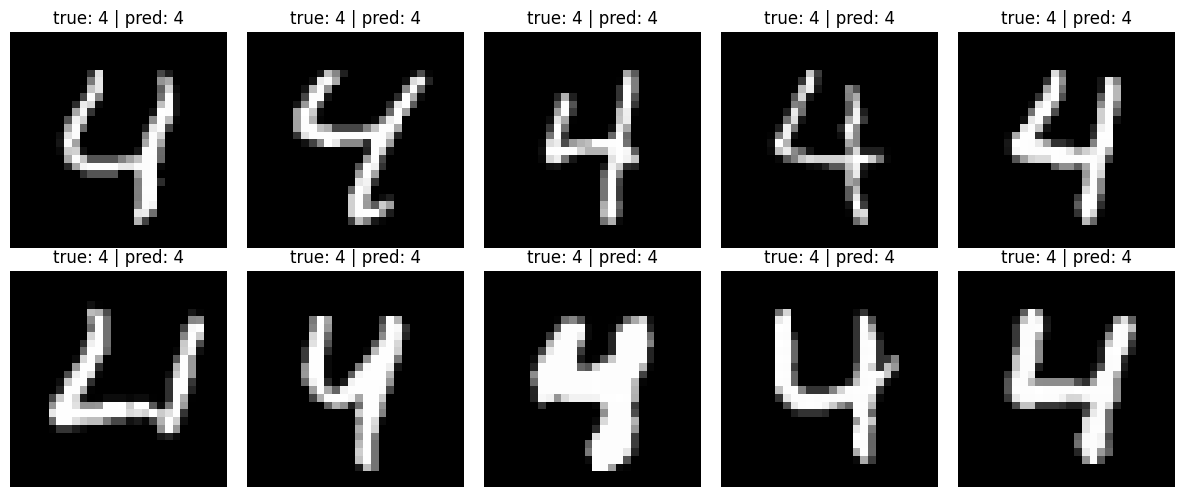

In [5]:
## Testing CNN visually
cnn.eval()
images, labels = next(iter(num_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    preds = cnn(images).argmax(1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].cpu().squeeze(), cmap='gray')
    ax.set_title(f"true: {labels[i].item()} | pred: {preds[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()



1.   Simple CNN defined in line with example code
2.   Tested before moving to next step to confirm it runs
3.   Test accuracy is 0.98.
4.   Visually confirmed that it works fine.




In [8]:
###################### Attack function#################
# https://github.com/jasonicarter/MNIST-adversarial-images/blob/master/MNIST-adversarial-images.ipynb

# Target class in this example is 9 (ref: lab 2)
#EV: I also added a few items to visualise the effect of the trick
def fgsm_targeted(model, x, target_class, lr=0.1, n_steps=5, verbose=False):
    x_adv = x.clone()
    target = torch.tensor([target_class]).to(device)
    steps_imgs = []

    for step in range(n_steps):
        x_adv.requires_grad_(True)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, target)
        model.zero_grad()
        loss.backward()
        grad_sign = x_adv.grad.sign()
        x_adv = (x_adv - lr * grad_sign).clamp(0, 1).detach()
        steps_imgs.append(x_adv.cpu().squeeze())

        if verbose:
            pred = logits.argmax(1).item()
            conf = F.softmax(logits, dim=1)[0, target_class].item()
            print(f"Step {step+1} | pred: {pred} | loss: {loss.item():.4f} | conf(9): {conf:.4f} | grad_sign mean: {grad_sign.abs().mean().item():.4f}")

    return x_adv, grad_sign, steps_imgs

In [12]:
sample = images[0].unsqueeze(0).to(device)
x_adv, grad_sign, steps_imgs = fgsm_targeted(cnn, sample, target_class, verbose=True)


Step 1 | pred: 4 | loss: 13.5566 | conf(9): 0.0000 | grad_sign mean: 1.0000
Step 2 | pred: 9 | loss: 0.0009 | conf(9): 0.9991 | grad_sign mean: 1.0000
Step 3 | pred: 9 | loss: 0.0000 | conf(9): 1.0000 | grad_sign mean: 1.0000
Step 4 | pred: 9 | loss: 0.1554 | conf(9): 0.8561 | grad_sign mean: 1.0000
Step 5 | pred: 9 | loss: 0.0000 | conf(9): 1.0000 | grad_sign mean: 1.0000


Overall, loss indicates here how "well" the model is fooled. At step 1, loss is quite high showing that the model is not tricked yet and still predicts 4 as 4. However next steps show a sharp drop in the loss and success to trick the model.Below the figures also show the evaluation of the figure 4 for each step.


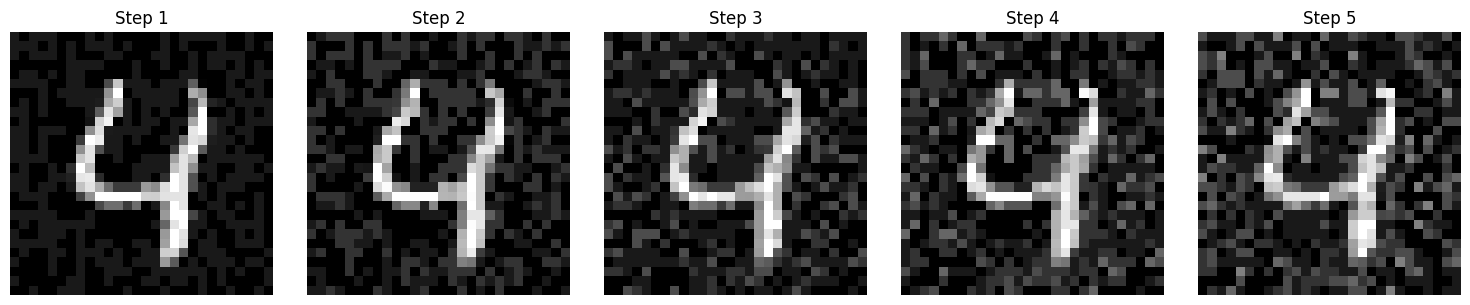

In [13]:
n_steps = 5
fig, axes = plt.subplots(1, n_steps, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(steps_imgs[i], cmap='gray')
    ax.set_title(f"Step {i+1}")
    ax.axis('off')
plt.tight_layout()
plt.show()

As it can be seen, each step adds a small structured perturbation to the pixel values. By step 2 the model is already fooled into predicting 9, yet the digit is still clearly recognisable as a 4 to the human eye.
This highlights the core vulnerability of the model; the CNN relies on pixel-level patterns rather than the semantic shape of the digit like humans do.

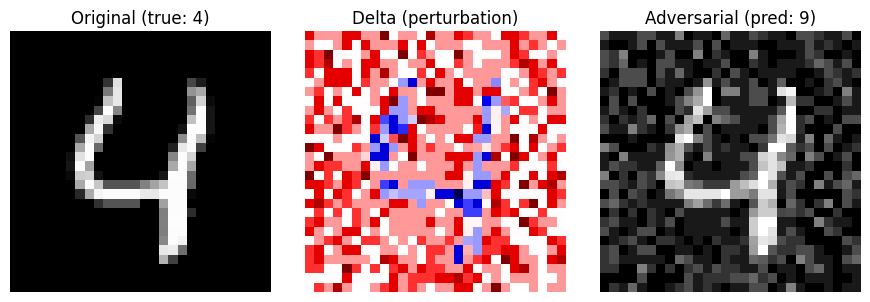

In [14]:
## Again following the footsteps of the reference code
delta = (x_adv - sample).cpu().squeeze()

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(sample.cpu().squeeze(), cmap='gray')
axes[0].set_title(f"Original (true: {source_class})")
axes[0].axis('off')

axes[1].imshow(delta, cmap='seismic', vmin=-0.5, vmax=0.5)
axes[1].set_title("Delta (perturbation)")
axes[1].axis('off')

axes[2].imshow(x_adv.cpu().squeeze(), cmap='gray')
axes[2].set_title(f"Adversarial (pred: {cnn(x_adv).argmax(1).item()})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

Red for positive push (intensity of the pixel is higher or overall lighter).
Blue vice-versa.

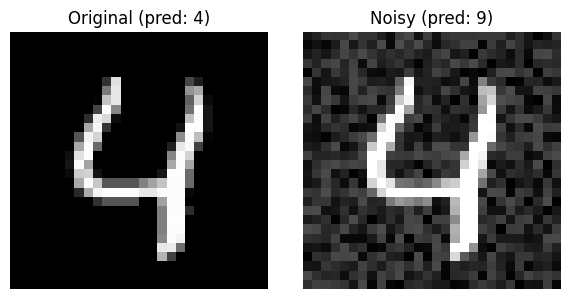

Noisy prediction: 0.3, 4


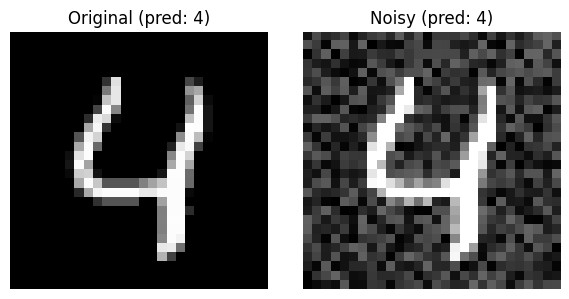

Noisy prediction: 0.4, 4


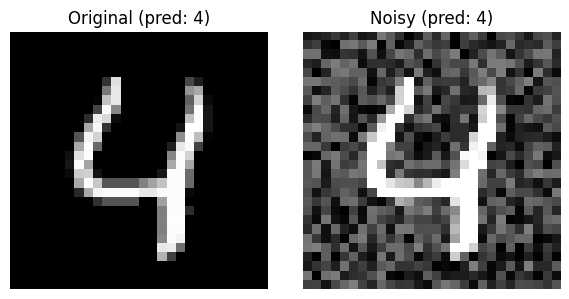

Noisy prediction: 0.5, 4


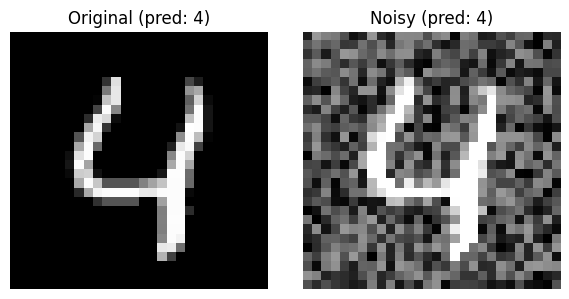

Noisy prediction: 0.6, 4


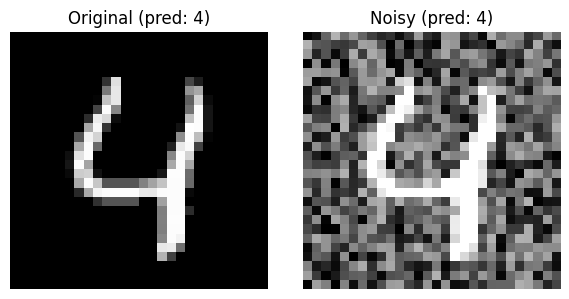

Noisy prediction: 0.7, 4


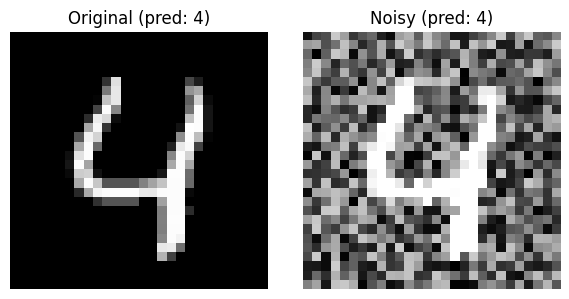

Noisy prediction: 0.8, 9


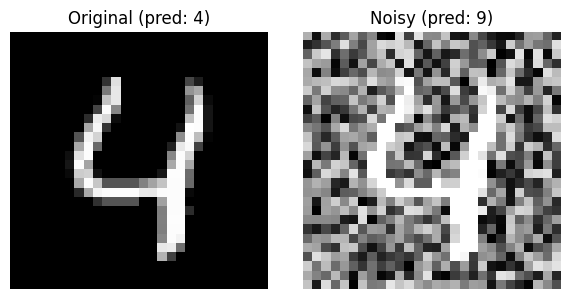

Noisy prediction: 0.9, 9


In [20]:
## Random noise
# testing epsilons
epsilons = [0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for epsilon in epsilons:

  x_noisy = sample + torch.rand_like(sample).to(device) * epsilon
  x_noisy = x_noisy.clamp(0, 1)

  fig, axes = plt.subplots(1, 2, figsize=(6, 3))

  axes[0].imshow(sample.cpu().squeeze(), cmap='gray')
  axes[0].set_title(f"Original (pred: {cnn(sample).argmax(1).item()})")
  axes[0].axis('off')

  axes[1].imshow(x_noisy.cpu().squeeze(), cmap='gray')
  axes[1].set_title(f"Noisy (pred: {pred})")
  axes[1].axis('off')

  plt.tight_layout()
  plt.show()

  with torch.no_grad():
      pred = cnn(x_noisy).argmax(1).item()

  print(f"Noisy prediction: {epsilon}, {pred}")

# Conclusion

Random noise requires epsilon=0.8 to fool the CNN, by which point the digit is heavily degraded and barely recognisable. FGSM achieves the same at epsilon=0.3 with the digit still clearly visible. The difference is not the magnitude but the structure. FGSM is designed to trick the model by calculating exactly which direction to push each pixel, random noise on the other hand does not.